In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer
from sensorium.utility.scores import get_correlations

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer
import utils.knn as knn
from models.whitener import Whitener

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file

]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

factorized_model_config_old = {
    'hidden_channels': 96, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 9, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
    'readout_type': 'factorized',
    'init_temp': 1,
    'factorize_spatial': True,
    'fourier_spatial': False,
    'fourier_max_freq': 4,
    # 'retinotopy_spatial': None,
    'retinotopy_spatial': {
        'hidden_features': 0,
        'hidden_layers': 0,
        'in_dim': None,
    },
    'whitener': Whitener(96, 0.003),
    'track_running_stats': True,
}

import copy
factorized_model_config_old['shift_layers'] = 1
factorized_model_config_old['shifter_bias'] = False
factorized_model_config_old['fourier_spatial'] = False
factorized_model_config_old['discretized_spatial'] = True
gaussian_model_config = copy.deepcopy(factorized_model_config_old)
gaussian_model_config['readout_type'] = 'gaussian'

factorized_model_config = copy.deepcopy(factorized_model_config_old)
# factorized_model_config['hidden_channels'] = 96
# factorized_model_config['input_kern'] = 9
# factorized_model_config['whitener'] = None
# factorized_model_config['shifter'] = False
# factorized_model_config['perspective'] = True
# factorized_model_config['retinotopy_spatial'] = {
#     # 'hidden_features': 20,
#     # 'hidden_layers': 3,
#     'in_dim': 4,
# }
# factorized_model_config['init_temp'] = 0.1
# factorized_model_config['normalize_logits'] = True
# factorized_model_config['shifter'] = False
# factorized_model_config['stochastic'] = True
# factorized_model_config['init_noise'] = 0.05
# factorized_model_config['hidden_channels_shifter'] = 5
# factorized_model_config['shift_layers'] = 1
# factorized_model_config['shifter_bias'] = False
# factorized_model_config['fourier_max_freq'] = 1
# factorized_model_config['diagonal'] = False
factorized_model_config['discretized_spatial'] = False
factorized_model_config['gaussian_spatial'] = True
factorized_model_config['covariance_type'] = 'full'
factorized_model_config['track_running_stats'] = False
# factorized_model_config['fourier_spatial'] = False

# factorized_model_config['shifter'] = False
# factorized_model_config['perspective'] = True
# factorized_model_config['retina_mlp_layers'] = 3
# factorized_model_config['retina_mlp_features'] = 16

In [ ]:
gaussian_paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

In [3]:
gaussian_scores = []
for path in gaussian_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **gaussian_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    model.readout.eval()
    gaussian_scores.append(get_correlations(model, dataloaders['validation'], device=device, per_neuron=False))
gaussian_scores

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


[np.float32(0.39820635), np.float32(0.3866408), np.float32(0.39601597)]

In [8]:
# factorized_paths = [
#     'runs/factorized/factorized_spatial_softmax1e-5_tem1e-1_featurereg/model_weights.pth',
#     'runs/factorized/factorized_spatial_softmax1e-5_tem1e-1_featurereg_seed42/model_weights.pth',
#     'runs/factorized/factorized_spatial_softmax1e-5_tem1e-1_featurereg_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/factorized1e-5_retinotopy_0layers_seed0/model_weights.pth',
#     'runs/factorized/factorized1e-5_retinotopy_0layers_seed42/model_weights.pth',
#     'runs/factorized/factorized1e-5_retinotopy_0layers_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/factorized1e-5_fullretinotopy_0layers_seed0/model_weights.pth',
#     'runs/factorized/factorized1e-5_fullretinotopy_0layers_seed42/model_weights.pth',
#     'runs/factorized/factorized1e-5_fullretinotopy_0layers_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/factorized_fourier4_0x0_seed0/model_weights.pth',
#     'runs/factorized/factorized_fourier4_0x0_seed42/model_weights.pth',
#     'runs/factorized/factorized_fourier4_0x0_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/factorized_sweepconf_seed0/model_weights.pth',
#     'runs/factorized/factorized_sweepconf_seed42/model_weights.pth',
#     'runs/factorized/factorized_sweepconf_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/single_fourier3_seed0/model_weights.pth',
#     'runs/factorized/single_fourier3_seed42/model_weights.pth',
#     'runs/factorized/single_fourier3_seed123/model_weights.pth',
# ]
factorized_paths_old = [
    'runs/factorized/fourier96_whitened_seed0/model_weights.pth',
    'runs/factorized/fourier96_whitened_seed42/model_weights.pth',
    'runs/factorized/fourier96_whitened_seed123/model_weights.pth',
]
# factorized_paths = [
#     'runs/factorized/fourier96_nonwhitened_seed0/model_weights.pth',
#     'runs/factorized/fourier96_nonwhitened_seed42/model_weights.pth',
#     'runs/factorized/fourier96_nonwhitened_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_tempanneal_seed0/model_weights.pth',
#     'runs/factorized/fourier96_tempanneal_seed42/model_weights.pth',
#     'runs/factorized/fourier96_tempanneal_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_freeze_readout_temp0.1_seed0/model_weights.pth',
#     'runs/factorized/fourier96_freeze_readout_temp0.1_seed42/model_weights.pth',
#     'runs/factorized/fourier96_freeze_readout_temp0.1_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_hard_seed0/model_weights.pth',
#     'runs/factorized/fourier96_hard_seed42/model_weights.pth',
#     'runs/factorized/fourier96_hard_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_tempanneal0.2_seed0/model_weights.pth',
#     'runs/factorized/fourier96_tempanneal0.2_seed42/model_weights.pth',
#     'runs/factorized/fourier96_tempanneal0.2_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_shifter20x1_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifter20x1_seed42/model_weights.pth',
#     'runs/factorized/fourier96_shifter20x1_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_shifter20x2_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifter20x2_seed42/model_weights.pth',
#     'runs/factorized/fourier96_shifter20x2_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_shifter20x3_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifter20x3_seed42/model_weights.pth',
#     'runs/factorized/fourier96_shifter20x3_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_perspective75_16x3_seed0/model_weights.pth',
#     'runs/factorized/fourier96_perspective75_16x3_seed42/model_weights.pth',
#     'runs/factorized/fourier96_perspective75_16x3_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_entropy1e9_seed0/model_weights.pth',
#     'runs/factorized/fourier96_entropy1e9_seed42/model_weights.pth',
#     'runs/factorized/fourier96_entropy1e9_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_nonwhite_entropy1e9_seed0/model_weights.pth',
#     'runs/factorized/fourier96_nonwhite_entropy1e9_seed42/model_weights.pth',
#     'runs/factorized/fourier96_nonwhite_entropy1e9_seed123/model_weights.pth',
#]
# factorized_paths = [
#     'runs/factorized/fourier96_noshift_seed0/model_weights.pth',
#     'runs/factorized/fourier96_noshift_seed42/model_weights.pth',
#     'runs/factorized/fourier96_noshift_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_gaussian_shifter0.05_seed0/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_shifter0.05_seed42/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_shifter0.05_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_correct_shifter_seed0/model_weights.pth',
#     'runs/factorized/fourier96_correct_shifter_seed42/model_weights.pth',
#     'runs/factorized/fourier96_correct_shifter_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_shifter_centered5x2_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifter_centered5x2_seed42/model_weights.pth',
#     'runs/factorized/fourier96_shifter_centered5x2_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_shifter_centered20x1_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifter_centered20x1_seed42/model_weights.pth',
#     'runs/factorized/fourier96_shifter_centered20x1_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_linear_seed0/model_weights.pth',
#     'runs/factorized/fourier96_linear_seed42/model_weights.pth',
#     'runs/factorized/fourier96_linear_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_linear_com1e4_seed0/model_weights.pth',
#     'runs/factorized/fourier96_linear_com1e4_seed42/model_weights.pth',
#     'runs/factorized/fourier96_linear_com1e4_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_linear_freq3_seed0/model_weights.pth',
#     'runs/factorized/fourier96_linear_freq3_seed42/model_weights.pth',
#     'runs/factorized/fourier96_linear_freq3_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_linear_freq4_diag_seed0/model_weights.pth',
#     'runs/factorized/fourier96_linear_freq4_diag_seed42/model_weights.pth',
#     'runs/factorized/fourier96_linear_freq4_diag_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_readoutcom1e0_seed0/model_weights.pth',
#     'runs/factorized/fourier96_readoutcom1e0_seed42/model_weights.pth',
#     'runs/factorized/fourier96_readoutcom1e0_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_gaussian_com_seed0/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_com_seed42/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_com_seed123/model_weights.pth',
# ]
# factorized_paths_old = [
#     'runs/factorized/fourier96_epoch_cp_seed0/model_weights.pth',
#     'runs/factorized/fourier96_epoch_cp_seed42/model_weights.pth',
#     'runs/factorized/fourier96_epoch_cp_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_gaussian_epoch_cp_seed0/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_epoch_cp_seed42/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_epoch_cp_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_discretized_smooth2_seed0/model_weights.pth',
#     'runs/factorized/fourier96_discretized_smooth2_seed42/model_weights.pth',
#     'runs/factorized/fourier96_discretized_smooth2_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_discretized_smooth2_2x2shifter_seed0/model_weights.pth',
#     'runs/factorized/fourier96_discretized_smooth2_2x2shifter_seed42/model_weights.pth',
#     'runs/factorized/fourier96_discretized_smooth2_2x2shifter_seed123/model_weights.pth',
# ]
factorized_paths_old = [
    'runs/factorized/fourier96_discretized_gain0.1_seed0/model_weights.pth',
    'runs/factorized/fourier96_discretized_gain0.1_seed42/model_weights.pth',
    'runs/factorized/fourier96_discretized_gain0.1_seed123/model_weights.pth',
]
# factorized_paths_old = [
#     'runs/factorized/fourier96_gain0.1_seed0/model_weights.pth',
#     'runs/factorized/fourier96_gain0.1_seed42/model_weights.pth',
#     'runs/factorized/fourier96_gain0.1_seed123/model_weights.pth',
# ]
# factorized_paths_old = [
#     'runs/factorized/fourier96_epoch_cp_2x2shift_seed0/model_weights.pth',
#     'runs/factorized/fourier96_epoch_cp_2x2shift_seed42/model_weights.pth',
#     'runs/factorized/fourier96_epoch_cp_2x2shift_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/fourier96_gaussian_epoch_cp_2x2shift_seed0/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_epoch_cp_2x2shift_seed42/model_weights.pth',
#     'runs/factorized/fourier96_gaussian_epoch_cp_2x2shift_seed123/model_weights.pth',
# ]
# factorized_paths = [
#     'runs/factorized/discretized96_retinotopy_shifter_seed0/model_weights.pth',
#     'runs/factorized/discretized96_retinotopy_shifter_seed42/model_weights.pth',
#     'runs/factorized/discretized96_retinotopy_shifter_seed123/model_weights.pth',
# ]
factorized_paths = [
    'runs/factorized/full_gaussian_seed0/model_weights.pth',
    'runs/factorized/full_gaussian_seed42/model_weights.pth',
    'runs/factorized/full_gaussian_seed123/model_weights.pth',
]

In [3]:
monitor_locs = []
monitor_angs = []
for path in factorized_paths:
    cp = torch.load(path, map_location='cpu')
    locs = []
    angs = []
    for k, v in cp.items():
        if 'monitor' in k and not 'std' in k and 'center' in k:
            locs.append(v)
        if 'monitor' in k and not 'std' in k and 'angle' in k:
            angs.append(v)
            print(k)
    
    monitor_locs.append(locs)
    monitor_angs.append(angs)

perspective.23343-5-17.monitor.angle
perspective.23964-4-22.monitor.angle
perspective.23656-14-22.monitor.angle
perspective.21067-10-18.monitor.angle
perspective.26872-17-20.monitor.angle
perspective.22846-10-16.monitor.angle
perspective.27204-5-13.monitor.angle
perspective.23343-5-17.monitor.angle
perspective.23964-4-22.monitor.angle
perspective.23656-14-22.monitor.angle
perspective.21067-10-18.monitor.angle
perspective.26872-17-20.monitor.angle
perspective.22846-10-16.monitor.angle
perspective.27204-5-13.monitor.angle
perspective.23343-5-17.monitor.angle
perspective.23964-4-22.monitor.angle
perspective.23656-14-22.monitor.angle
perspective.21067-10-18.monitor.angle
perspective.26872-17-20.monitor.angle
perspective.22846-10-16.monitor.angle
perspective.27204-5-13.monitor.angle


In [22]:
print('monitor positions')
for i in range(7):
    for j in range(3):
        print(f'seed {['0  ', '42 ' , '123'][j]} {np.array(monitor_locs)[j, i, :]}')
    print()

print('monitor angles')
for i in range(7):
    for j in range(3):
        print(f'seed {['0  ', '42 ' , '123'][j]} {np.array(monitor_angs)[j, i, :]}')
    print()

monitor positions
seed 0   [-0.0380358   0.04284293  0.5852621 ]
seed 42  [-0.02990766 -0.00277294  0.52861685]
seed 123 [-0.10496119 -0.03580315  0.5735173 ]

seed 0   [0.02839019 0.01968061 0.5435553 ]
seed 42  [-0.03683289 -0.11351648  0.47490445]
seed 123 [-0.01426715 -0.09319112  0.52403235]

seed 0   [-0.08250667 -0.09962954  0.51886964]
seed 42  [ 0.02737118 -0.100451    0.48603806]
seed 123 [-0.02454394 -0.0936389   0.5114228 ]

seed 0   [-0.06018471  0.0629443   0.57417923]
seed 42  [-0.0954041  -0.08877831  0.49106532]
seed 123 [-0.12855    -0.07882999  0.5517946 ]

seed 0   [ 0.22776146 -0.23604587  0.4255855 ]
seed 42  [-0.2299763  -0.26440737  0.38489953]
seed 123 [ 0.13064599 -0.13018832  0.5327191 ]

seed 0   [0.01829003 0.07807229 0.5361514 ]
seed 42  [-0.07902199 -0.03370895  0.47648412]
seed 123 [-0.01659806  0.07764519  0.530382  ]

seed 0   [-0.05891401  0.11455251  0.5517391 ]
seed 42  [-0.09682633 -0.00324654  0.5234828 ]
seed 123 [-0.01779734  0.06531014  0.56031

In [4]:
factorized_model_config_old

{'hidden_channels': 96,
 'depth_separable': False,
 'use_avg_reg': False,
 'laplace_padding': None,
 'momentum': 0.75,
 'final_nonlinearity': True,
 'nonlinearity_type': 'AdaptiveELU',
 'pad_input': False,
 'stack': -1,
 'layers': 4,
 'input_kern': 9,
 'gamma_input': 6.3831,
 'feature_reg_weight': 3,
 'hidden_kern': 7,
 'grid_mean_predictor': {'type': 'cortex',
  'input_dimensions': 2,
  'hidden_layers': 1,
  'hidden_features': 30,
  'final_tanh': True},
 'init_sigma': 0.1,
 'init_mu_range': 0.3,
 'gauss_type': 'full',
 'shifter': True,
 'batch_norm_scale': [True, True, True, False],
 'core_bias': [True, True, True, False],
 'regularizer_type': 'adaptive_log_norm',
 'gamma_sigma': 0.25,
 'readout_type': 'factorized',
 'init_temp': 1,
 'factorize_spatial': False,
 'fourier_spatial': False,
 'fourier_max_freq': 4,
 'retinotopy_spatial': {'hidden_features': 0, 'hidden_layers': 0},
 'whitener': Whitener(),
 'shift_layers': 1,
 'shifter_bias': False,
 'discretized_spatial': True}

In [6]:
factorized_scores_old = []
for path in factorized_paths_old:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config_old)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    factorized_scores_old.append(get_correlations(model, dataloaders['validation'], device=device, per_neuron=False))
factorized_scores_old

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


[np.float32(0.4076492), np.float32(0.39979827), np.float32(0.40490705)]

In [9]:
factorized_scores = []
for path in factorized_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    factorized_scores.append(get_correlations(model, dataloaders['validation'], device=device, per_neuron=False))
factorized_scores

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


[np.float32(0.4102145), np.float32(0.4089488), np.float32(0.41004106)]

In [13]:
num_batches = 10
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
n_clusters_range = np.unique(np.geomspace(2, 90, num=20, dtype=int))
gaussian_readouts = []

for path in gaussian_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **gaussian_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    model.readout.eval()

    # train_feature_vecs = []

    # for key in data_keys:
    #     batch_count = 0
    #     for batch in dataloaders['train'][key]:
    #         batch_count += 1
    #         img, _, _, pupil = batch
            
    #         pred, feature_vec = model(img, data_key=key, pupil_center=pupil, return_vec=True)
    #         train_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 3).flatten(0, 2))

    #         if batch_count == num_batches:
    #             break

    # # whiten based on feature maps
    # X_train = torch.cat(train_feature_vecs)

    # # compute cov
    # mu = X_train.mean(dim=0, keepdims=True)
    # Xc = X_train - mu
    # cov = Xc.T @ Xc / (Xc.shape[0] - 1)

    # # get whitening matrix from cov
    # L = torch.linalg.cholesky(cov)
    # Winv = L.T

    # readouts = torch.cat([(Winv @ model.readout[key].features.detach().cpu().squeeze()).T for key in data_keys])
    readouts = torch.cat([(model.readout[key].features.detach().cpu().squeeze()).T for key in data_keys])
    gaussian_readouts.append(readouts)
    
gaussian_curve = knn.get_curve(gaussian_readouts, k_range)
# gaussian_curve = knn.get_ari_curve(n_clusters_range, gaussian_readouts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


RuntimeError: Error(s) in loading state_dict for FiringRateEncoder:
	Missing key(s) in state_dict: "readout.23343-5-17.whitener.mu_ema", "readout.23343-5-17.whitener.cov_ema", "readout.23964-4-22.whitener.mu_ema", "readout.23964-4-22.whitener.cov_ema", "readout.23656-14-22.whitener.mu_ema", "readout.23656-14-22.whitener.cov_ema", "readout.21067-10-18.whitener.mu_ema", "readout.21067-10-18.whitener.cov_ema", "readout.26872-17-20.whitener.mu_ema", "readout.26872-17-20.whitener.cov_ema", "readout.22846-10-16.whitener.mu_ema", "readout.22846-10-16.whitener.cov_ema", "readout.27204-5-13.whitener.mu_ema", "readout.27204-5-13.whitener.cov_ema". 
	size mismatch for core.features.layer0.conv.weight: copying a param with shape torch.Size([64, 4, 11, 11]) from checkpoint, the shape in current model is torch.Size([96, 4, 9, 9]).
	size mismatch for core.features.layer0.norm.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([96]).
	size mis

In [8]:
num_batches = 10
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
n_clusters_range = np.unique(np.geomspace(2, 90, num=20, dtype=int))
factorized_readouts = []
covs = []

for path in factorized_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()

    train_feature_vecs = []

    for key in data_keys:
        batch_count = 0
        for batch in dataloaders['train'][key]:
            batch_count += 1
            img, _, _, pupil = batch
            
            pred, feature_vec = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            train_feature_vecs.append(feature_vec.detach().cpu().transpose(1, 2).flatten(0, 1))

            if batch_count == num_batches:
                break

    # whiten based on feature maps
    X_train = torch.cat(train_feature_vecs)

    # compute cov
    mu = X_train.mean(dim=0, keepdims=True)
    Xc = X_train - mu
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)
    covs.append(cov.cpu())

    # get whitening matrix from cov
    L = torch.linalg.cholesky(cov)
    Winv = L.T

    readouts = torch.cat([(Winv @ model.readout[key].features.detach().cpu().T).T for key in data_keys])
    # readouts = torch.cat([(model.readout[key].features.detach().T).T for key in data_keys])
    # readouts = model.readout[data_keys[0]].whitener.whiten_readouts(readouts.T).cpu().squeeze().T
    factorized_readouts.append(readouts.cpu())
    
factorized_curve = knn.get_curve(factorized_readouts, k_range)
# factorized_curve = knn.get_ari_curve(n_clusters_range, factorized_readouts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [10]:
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
n_clusters_range = np.unique(np.geomspace(2, 90, num=20, dtype=int))
factorized_readouts_old = []

for path in factorized_paths_old:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config_old)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()

    readouts = torch.cat([(model.readout[key].features.detach().T).T for key in data_keys])
    readouts = model.readout[data_keys[0]].whitener.whiten_readouts(readouts.T).cpu().squeeze().T
    factorized_readouts_old.append(readouts.cpu())
    
factorized_curve_old = knn.get_curve(factorized_readouts_old, k_range)
# factorized_curve_old = knn.get_ari_curve(n_clusters_range, factorized_white_readouts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [11]:
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
n_clusters_range = np.unique(np.geomspace(2, 90, num=20, dtype=int))
factorized_readouts = []

for path in factorized_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()

    readouts = torch.cat([(model.readout[key].features.detach().T).T for key in data_keys])
    readouts = model.readout[data_keys[0]].whitener.whiten_readouts(readouts.T).cpu().squeeze().T
    factorized_readouts.append(readouts.cpu())
    
factorized_curve = knn.get_curve(factorized_readouts, k_range)
# factorized_curve = knn.get_ari_curve(n_clusters_range, factorized_readouts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


# entropy reg debug

In [12]:
# path = 'runs/factorized/fourier96_whitened_seed0/model_weights.pth'
path = 'runs/factorized/fourier96_nonwhite_entropy1e9_seed0/model_weights.pth'
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
n_clusters_range = np.unique(np.geomspace(2, 90, num=20, dtype=int))

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
model.load_state_dict(torch.load(path, map_location=device))
model.to(device)
model.train()

readouts = [(model.readout[key].features.detach().T).T.cpu() for key in data_keys]
# readouts = [model.readout[data_keys[0]].whitener.whiten_readouts(r.T).cpu().squeeze().T for r in readouts]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


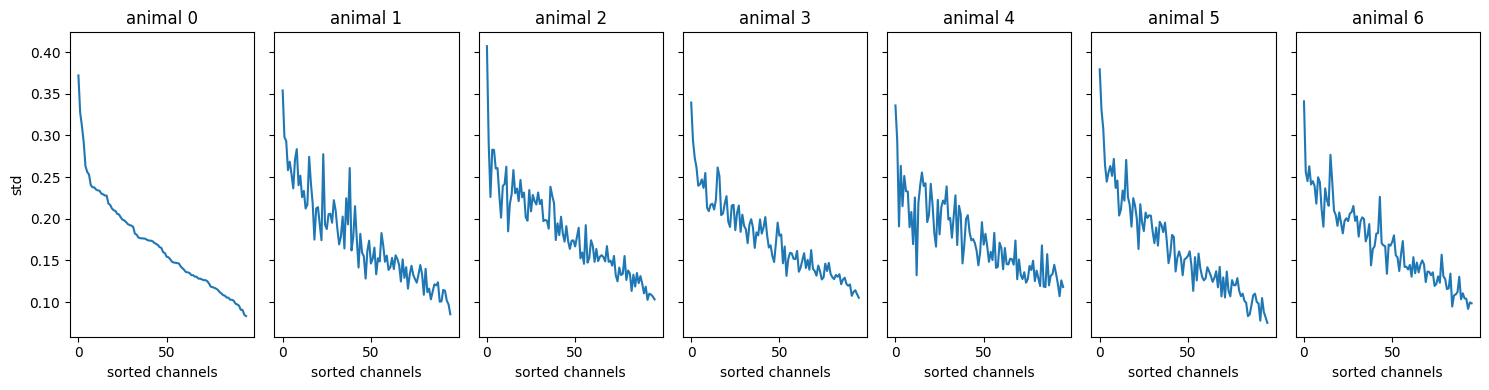

In [16]:
fig, axs = plt.subplots(1, 7, figsize=(15, 4), sharex=True, sharey=True)

std, idcs = readouts[0].std(0).sort()

for i in range(7):
    r = readouts[i]
    std = r.std(0)
    sortd = std[idcs]
    axs[i].plot(sortd.flip(0))
    axs[i].set_title(f'animal {i}')
    if i == 0:
        axs[i].set_ylabel('std')
    axs[i].set_xlabel('sorted channels')
plt.tight_layout()
plt.show()

In [9]:
factorized_curve

(array([0.88977258, 0.87924768, 0.83370697, 0.77937107, 0.73038294,
        0.69052026, 0.63413141, 0.5852718 , 0.5575763 , 0.53641669,
        0.52142707, 0.51139683, 0.50442642, 0.50062179, 0.4998183 ,
        0.50099827, 0.50407197]),
 array([0.00614268, 0.00572911, 0.00789806, 0.01131685, 0.01419367,
        0.01703841, 0.0212446 , 0.02611024, 0.02872644, 0.03076044,
        0.03230828, 0.0336326 , 0.03475013, 0.03571852, 0.03626522,
        0.03665702, 0.03682747]),
 array([[0.88528285, 0.887262  , 0.89677289],
        [0.87435174, 0.87784273, 0.88554857],
        [0.826501  , 0.83246898, 0.84215092],
        [0.76898056, 0.77770346, 0.7914292 ],
        [0.71753193, 0.72799941, 0.74561748],
        [0.6753743 , 0.68721863, 0.70896785],
        [0.61557157, 0.62951951, 0.65730314],
        [0.56303362, 0.57876017, 0.61402161],
        [0.53367035, 0.54961477, 0.58944377],
        [0.51094435, 0.52771517, 0.57059055],
        [0.49471232, 0.51223302, 0.55733587],
        [0.4838600

In [10]:
model

FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(4, 96, kernel_size=(9, 9), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(96, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))


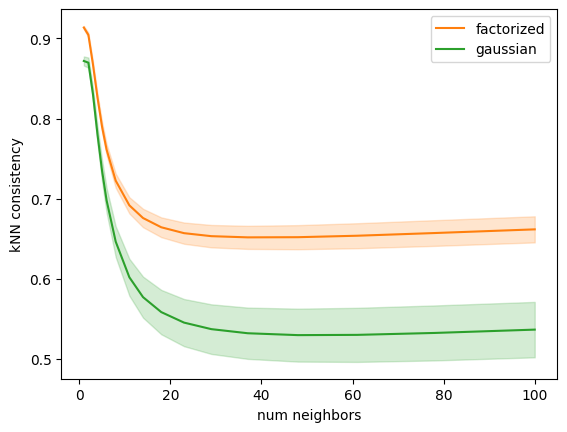

In [ ]:
# Get the default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for curve, label, color in zip(
    [factorized_curve_old, factorized_curve], 
    ['factorized', 'gaussian'],
    colors[1:7]
):
    m = curve[0]
    s = curve[1]
    plt.plot(k_range, m, color=color, label=label)
    plt.fill_between(k_range, m - s, m + s, alpha=0.2, color=color)

plt.legend()
plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.show()

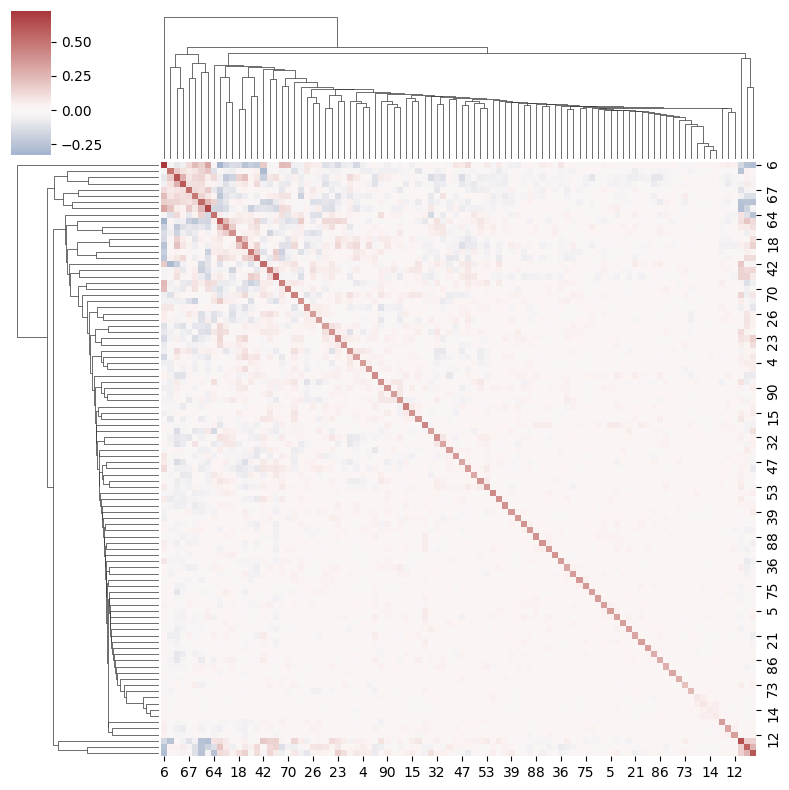

In [24]:
sns.clustermap(covs[2], cmap='vlag', center=0, figsize=(8, 8))
plt.show()

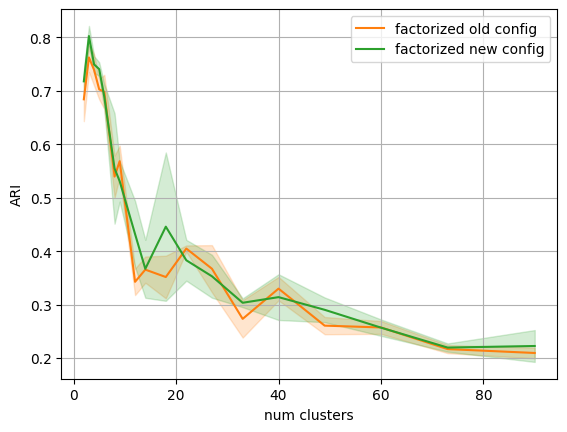

In [5]:
# Get the default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for curve, label, color in zip(
    [factorized_curve, factorized_white_curve], 
    ['factorized old config', 'factorized new config'],
    colors[1:7]
):
    m = np.array(curve[0])
    s = np.array(curve[1])
    plt.plot(n_clusters_range, m, color=color, label=label)
    plt.fill_between(n_clusters_range, m - s, m + s, alpha=0.2, color=color)

plt.legend()
plt.grid()
plt.xlabel('num clusters')
plt.ylabel('ARI')
plt.show()

# model prediction correlations

In [8]:
num_batches = 5
preds = [
    [[] for _ in range(7)] 
    for _ in range(len(factorized_paths))
]
targets = [
    [[] for _ in range(7)] 
    for _ in range(len(factorized_paths))
]
models = []

for path in factorized_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    model.readout.eval()
    models.append(model)

for i, key in enumerate(data_keys):
    batch_count = 0
    for batch in dataloaders['validation'][key]:
        batch_count += 1
        img, target, _, pupil = batch
        
        for j, model in enumerate(models):
            with torch.no_grad():
                pred = model(img, data_key=key, pupil_center=pupil).cpu()
                preds[j][i].append(pred)
            targets[j][i].append(target.cpu())
        
        if batch_count == num_batches:
            break

for i in range(len(factorized_paths)):
    for j in range(7):
        preds[i][j] = torch.cat(preds[i][j])
        targets[i][j] = torch.cat(targets[i][j])
    # preds[i] = torch.cat(preds[i], dim=1)
    # targets[i] = torch.cat(targets[i], dim=1)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


Parameter containing:
tensor([[-0.8464, -1.3209],
        [-0.7597,  0.9730]], requires_grad=True)
Parameter containing:
tensor([[-0.0437,  1.9501],
        [-0.5567, -0.1844]], requires_grad=True)
Parameter containing:
tensor([[ 0.4725, -0.1970],
        [-1.0027,  0.6745]], requires_grad=True)
Parameter containing:
tensor([[-0.1782, -0.3791],
        [-0.7745,  0.0924]], requires_grad=True)
Parameter containing:
tensor([[-0.3370, -0.2396],
        [ 0.7806,  1.4687]], requires_grad=True)
Parameter containing:
tensor([[-0.4561, -0.6877],
        [-1.0064,  0.7387]], requires_grad=True)
Parameter containing:
tensor([[-0.7421, -0.1405],
        [-0.5288, -0.4051]], requires_grad=True)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


Parameter containing:
tensor([[-0.8464, -1.3209],
        [-0.7597,  0.9730]], requires_grad=True)
Parameter containing:
tensor([[-0.0437,  1.9501],
        [-0.5567, -0.1844]], requires_grad=True)
Parameter containing:
tensor([[ 0.4725, -0.1970],
        [-1.0027,  0.6745]], requires_grad=True)
Parameter containing:
tensor([[-0.1782, -0.3791],
        [-0.7745,  0.0924]], requires_grad=True)
Parameter containing:
tensor([[-0.3370, -0.2396],
        [ 0.7806,  1.4687]], requires_grad=True)
Parameter containing:
tensor([[-0.4561, -0.6877],
        [-1.0064,  0.7387]], requires_grad=True)
Parameter containing:
tensor([[-0.7421, -0.1405],
        [-0.5288, -0.4051]], requires_grad=True)


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


Parameter containing:
tensor([[-0.8464, -1.3209],
        [-0.7597,  0.9730]], requires_grad=True)
Parameter containing:
tensor([[-0.0437,  1.9501],
        [-0.5567, -0.1844]], requires_grad=True)
Parameter containing:
tensor([[ 0.4725, -0.1970],
        [-1.0027,  0.6745]], requires_grad=True)
Parameter containing:
tensor([[-0.1782, -0.3791],
        [-0.7745,  0.0924]], requires_grad=True)
Parameter containing:
tensor([[-0.3370, -0.2396],
        [ 0.7806,  1.4687]], requires_grad=True)
Parameter containing:
tensor([[-0.4561, -0.6877],
        [-1.0064,  0.7387]], requires_grad=True)
Parameter containing:
tensor([[-0.7421, -0.1405],
        [-0.5288, -0.4051]], requires_grad=True)


In [9]:
idcs, jdcs = torch.tril_indices(len(factorized_paths), len(factorized_paths), offset=-1)
factorized_corrs = []
for i, j in zip(idcs, jdcs):
    pair_corrs = []
    for k in range(7):
        X = preds[i][k]
        Y = preds[j][k]

        corr = torch.nn.functional.cosine_similarity(
            X - X.mean(0, keepdim=True),
            Y - Y.mean(0, keepdim=True),
            dim=0
        )
        pair_corrs.append(corr)
    factorized_corrs.append(torch.cat(pair_corrs))
factorized_corrs = torch.stack(factorized_corrs)

In [9]:
factorized_corrs.mean(dim=1)

tensor([0.8969, 0.8968, 0.8989])

In [10]:
num_batches = 5
preds = [
    [[] for _ in range(7)] 
    for _ in range(len(factorized_paths_old))
]
targets = [
    [[] for _ in range(7)] 
    for _ in range(len(factorized_paths_old))
]
models = []

for path in factorized_paths_old:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config_old)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    model.readout.eval()
    models.append(model)

for i, key in enumerate(data_keys):
    batch_count = 0
    for batch in dataloaders['validation'][key]:
        batch_count += 1
        img, target, _, pupil = batch
        
        for j, model in enumerate(models):
            with torch.no_grad():
                pred = model(img, data_key=key, pupil_center=pupil).cpu()
                preds[j][i].append(pred)
            targets[j][i].append(target.cpu())
        
        if batch_count == num_batches:
            break

for i in range(len(factorized_paths_old)):
    for j in range(7):
        preds[i][j] = torch.cat(preds[i][j])
        targets[i][j] = torch.cat(targets[i][j])
    # preds[i] = torch.cat(preds[i], dim=1)
    # targets[i] = torch.cat(targets[i], dim=1)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


Parameter containing:
tensor([[-0.7023,  0.5181],
        [ 0.1712,  0.3456],
        [-0.5014,  0.1743],
        [ 0.2339,  0.9186],
        [ 0.2773, -0.2245]], requires_grad=True)
Parameter containing:
tensor([[-0.1891,  0.7118,  0.4620,  0.6925, -0.7814],
        [ 0.0431,  0.1533, -0.5775,  0.7020,  0.2775],
        [-0.6749,  0.6006, -0.3999,  0.3874,  0.2791],
        [-0.3484,  0.2235, -0.1464,  0.5964, -0.0369],
        [ 0.0014,  0.7385, -0.6152,  1.0670,  0.0595]], requires_grad=True)
Parameter containing:
tensor([[-0.4010, -0.0201, -0.3576, -0.5476, -0.1261],
        [-0.7111, -0.8948,  0.9263, -0.2246,  0.0228]], requires_grad=True)
Parameter containing:
tensor([[-9.2289e-02, -4.5486e-02],
        [-1.0669e-01, -4.6669e-01],
        [-6.9497e-01,  1.1301e-01],
        [ 1.0467e-03, -3.5296e-01],
        [-1.6438e+00, -5.2308e-01]], requires_grad=True)
Parameter containing:
tensor([[-0.4677, -0.6044, -0.1577,  0.0024, -0.5864],
        [ 0.4055, -0.1452,  0.1206, -0.4538, -

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


Parameter containing:
tensor([[-0.7023,  0.5181],
        [ 0.1712,  0.3456],
        [-0.5014,  0.1743],
        [ 0.2339,  0.9186],
        [ 0.2773, -0.2245]], requires_grad=True)
Parameter containing:
tensor([[-0.1891,  0.7118,  0.4620,  0.6925, -0.7814],
        [ 0.0431,  0.1533, -0.5775,  0.7020,  0.2775],
        [-0.6749,  0.6006, -0.3999,  0.3874,  0.2791],
        [-0.3484,  0.2235, -0.1464,  0.5964, -0.0369],
        [ 0.0014,  0.7385, -0.6152,  1.0670,  0.0595]], requires_grad=True)
Parameter containing:
tensor([[-0.4010, -0.0201, -0.3576, -0.5476, -0.1261],
        [-0.7111, -0.8948,  0.9263, -0.2246,  0.0228]], requires_grad=True)
Parameter containing:
tensor([[-9.2289e-02, -4.5486e-02],
        [-1.0669e-01, -4.6669e-01],
        [-6.9497e-01,  1.1301e-01],
        [ 1.0467e-03, -3.5296e-01],
        [-1.6438e+00, -5.2308e-01]], requires_grad=True)
Parameter containing:
tensor([[-0.4677, -0.6044, -0.1577,  0.0024, -0.5864],
        [ 0.4055, -0.1452,  0.1206, -0.4538, -

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


Parameter containing:
tensor([[-0.7023,  0.5181],
        [ 0.1712,  0.3456],
        [-0.5014,  0.1743],
        [ 0.2339,  0.9186],
        [ 0.2773, -0.2245]], requires_grad=True)
Parameter containing:
tensor([[-0.1891,  0.7118,  0.4620,  0.6925, -0.7814],
        [ 0.0431,  0.1533, -0.5775,  0.7020,  0.2775],
        [-0.6749,  0.6006, -0.3999,  0.3874,  0.2791],
        [-0.3484,  0.2235, -0.1464,  0.5964, -0.0369],
        [ 0.0014,  0.7385, -0.6152,  1.0670,  0.0595]], requires_grad=True)
Parameter containing:
tensor([[-0.4010, -0.0201, -0.3576, -0.5476, -0.1261],
        [-0.7111, -0.8948,  0.9263, -0.2246,  0.0228]], requires_grad=True)
Parameter containing:
tensor([[-9.2289e-02, -4.5486e-02],
        [-1.0669e-01, -4.6669e-01],
        [-6.9497e-01,  1.1301e-01],
        [ 1.0467e-03, -3.5296e-01],
        [-1.6438e+00, -5.2308e-01]], requires_grad=True)
Parameter containing:
tensor([[-0.4677, -0.6044, -0.1577,  0.0024, -0.5864],
        [ 0.4055, -0.1452,  0.1206, -0.4538, -

In [11]:
idcs, jdcs = torch.tril_indices(len(factorized_paths_old), len(factorized_paths_old), offset=-1)
factorized_corrs_old = []
for i, j in zip(idcs, jdcs):
    pair_corrs = []
    for k in range(7):
        X = preds[i][k]
        Y = preds[j][k]

        corr = torch.nn.functional.cosine_similarity(
            X - X.mean(0, keepdim=True),
            Y - Y.mean(0, keepdim=True),
            dim=0
        )
        pair_corrs.append(corr)
    factorized_corrs_old.append(torch.cat(pair_corrs))
factorized_corrs_old = torch.stack(factorized_corrs_old)

In [12]:
factorized_corrs_old.mean(dim=1)

tensor([0.7877, 0.7786, 0.7770])

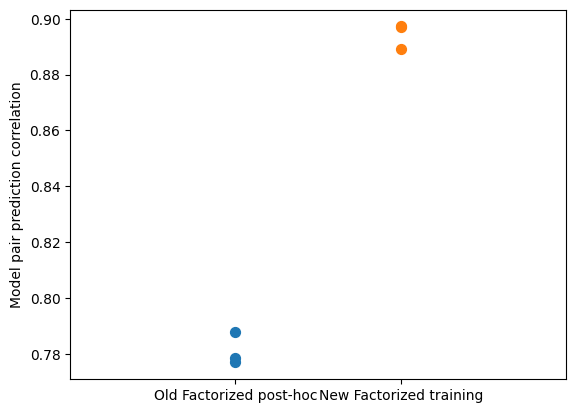

In [14]:
import matplotlib.pyplot as plt
import torch

fact = factorized_corrs_old.mean(dim=1).cpu()
new_fact = factorized_corrs.mean(dim=1).cpu()

plt.scatter(
    [0.0, 0.0, 0.0],
    fact,
    s=50,
)

plt.scatter(
    [1.0, 1.0, 1.0],
    new_fact,
    s=50,
)

plt.xticks([0, 1], ["Old Factorized post-hoc", "New Factorized training"])
plt.xlim(-1, 2)
plt.ylabel("Model pair prediction correlation")
plt.show()

# factorized mask comparison

In [14]:
spatial = []

for path in factorized_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    model.readout.eval()

    spatial.append([model.readout[key].normalized_spatial().detach().cpu() for key in data_keys])

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


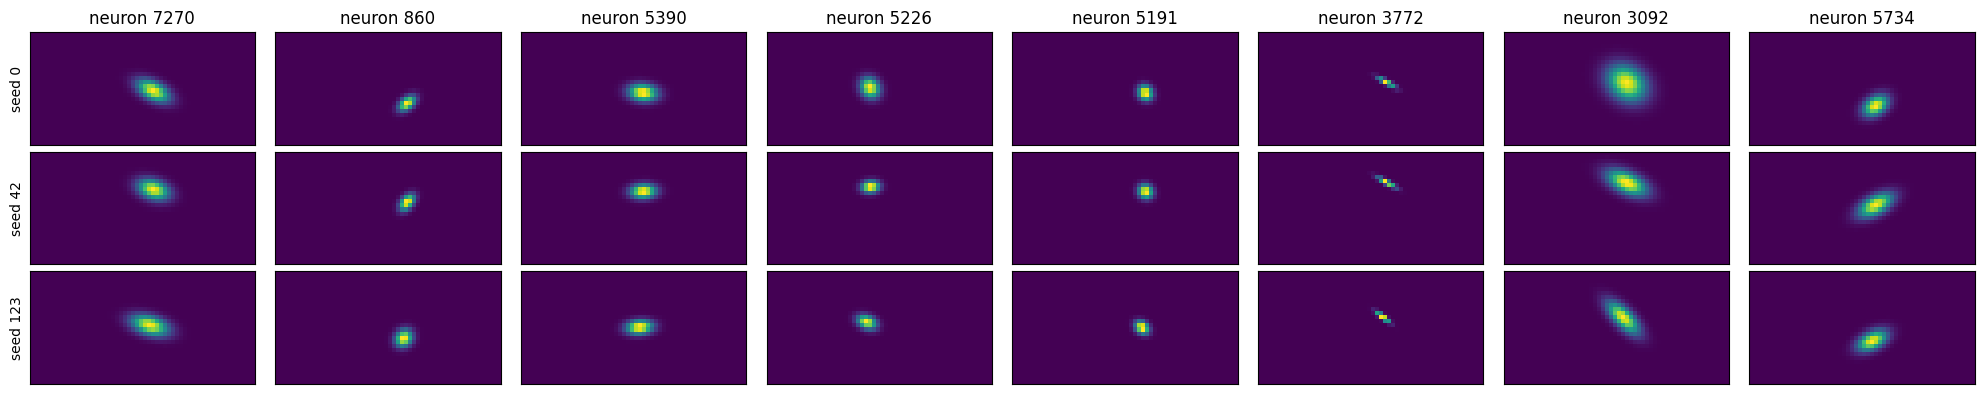

In [15]:
animal_idx = 6
n = 8
idcs = np.random.choice(spatial[0][animal_idx].shape[0], n)
fig, axs = plt.subplots(3, n, figsize=(20, 4))
for i, idx in enumerate(idcs):
    for j, s in enumerate(spatial):
        axs[j, i].imshow(s[animal_idx][idx])
        axs[j, i].set_xticks([])
        axs[j, i].set_yticks([])
        if i == 0:
            axs[j, i].set_ylabel(f'seed {[0, 42, 123][j]}')
        if j == 0:
            axs[j, i].set_title(f'neuron {idcs[i]}')
plt.tight_layout()

In [11]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
model.load_state_dict(torch.load(factorized_paths[0], map_location=device))
model.to(device)
model.train()
model.readout.eval()


# Create a grid of (h_pos, w_pos) input points
n = 8  # grid size
h_vals = torch.linspace(-1, 1, n, dtype=torch.float32, device=device)
w_vals = torch.linspace(-1, 1, n, dtype=torch.float32, device=device)

# Shape: (n*n, 2)
grid_h, grid_w = torch.meshgrid(h_vals, w_vals, indexing='ij')
inp = torch.stack([grid_h.flatten(), grid_w.flatten()], dim=1)

h, w = 28, 56

# h_vec = model.readout[data_keys[0]].retinotopy_spatial.h_mlp(inp).detach().cpu().unsqueeze(2)  # (n*n, h, 1)
# w_vec = model.readout[data_keys[0]].retinotopy_spatial.w_mlp(inp).detach().cpu().unsqueeze(1)  # (n*n, 1, w)

# single_spatial = h_vec.expand(-1, h, w) * w_vec.expand(-1, h, w)  # (n*n, h, w)
# single_spatial = model.readout[data_keys[0]].retinotopy_spatial.mlp(inp).detach().cpu().view(-1, h, w)
animal_id = 1
# single_spatial = model.readout[data_keys[animal_id]].retinotopy_spatial.mlp(inp).detach().cpu()
coeffs = model.readout[data_keys[animal_id]].retinotopy_spatial.mlp(inp).detach().cpu()
basis = model.readout[data_keys[animal_id]].retinotopy_spatial.basis.detach().cpu()
k = coeffs.shape[1]
print(coeffs.shape, basis.shape)
import math
single_spatial = torch.einsum("nk,khw->nhw", coeffs, basis) / math.sqrt(k)
print(single_spatial.shape)

weight = torch.nn.functional.softmax(
    single_spatial.view(-1, h * w) / 0.1, dim=1
).view(-1, h, w)

fig, axs = plt.subplots(n, n, figsize=(n * 2, n * 1))
# for i in range(n):
#     for j in range(n):
#         ax = axs[i, j]
#         ax.imshow(weight[i * n + j])
#         ax.set_xticks([])
#         ax.set_yticks([])
# fig, axs = plt.subplots(n, n, figsize=(n * 0.8, n * 0.4))
for i in range(n):
    for j in range(n):
        ax = axs[i, j]
        ax.imshow(weight[j * n + i])
        ax.set_xticks([])
        ax.set_yticks([])

        # Label left edge with h value
        if j == 0:
            ax.set_ylabel(f"{h_vals[i]:.2f}", fontsize=8, rotation=0, labelpad=18, va='center')

        # Label top edge with w value
        if i == 0:
            ax.set_title(f"{w_vals[j]:.2f}", fontsize=8, pad=2)

# Axis titles
fig.text(0.04, 0.46, "y position", va='center', rotation='vertical', fontsize=10)
fig.text(0.54, 0.97, "x position", ha='center', va='top', fontsize=10)

plt.tight_layout(rect=[0.04, 0, 1, 0.96])
plt.show()

plt.tight_layout()
plt.show()

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


AttributeError: 'GaussianRetinotopy' object has no attribute 'basis'

# mean mask comparisons

## gaussian

In [26]:
tnum_batches = 3

gaussian_grids = []
gaussian_shifts = []

for path in gaussian_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **gaussian_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.train();

    model_grids = []
    model_shifts = []

    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).detach().cpu().squeeze()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * 54  # rescale to from [-1, 1] to [0, w] 
        grid[:, 1] = (grid[:, 1] + 1) / 2 * 26  # rescale to from [-1, 1] to [0, h] 
        grid_mean = grid.mean(0, keepdim=True)
        
        grid_centered = grid - grid_mean
        
        batch_num = 0

        shifts_batches = []
        for batch in dataloaders['validation'][key]:
            batch_num += 1
            img, _, _, pupil = batch
            shift = model.shifter[key](pupil, None).detach().cpu()
            shift[:, 0] = shift[:, 0] / 2 * 54  # rescale to from [-1, 1] to [-w/2, w/2] 
            shift[:, 1] = shift[:, 1] / 2 * 26  # rescale to from [-1, 1] to [-h/2, h/2]
            shift = shift + grid_mean
            shifts_batches.append(shift)

            if batch_num == num_batches:
                break
            
        model_grids.append(grid_centered)
        model_shifts.append(torch.cat(shifts_batches))
    gaussian_grids.append(model_grids)
    gaussian_shifts.append(model_shifts)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


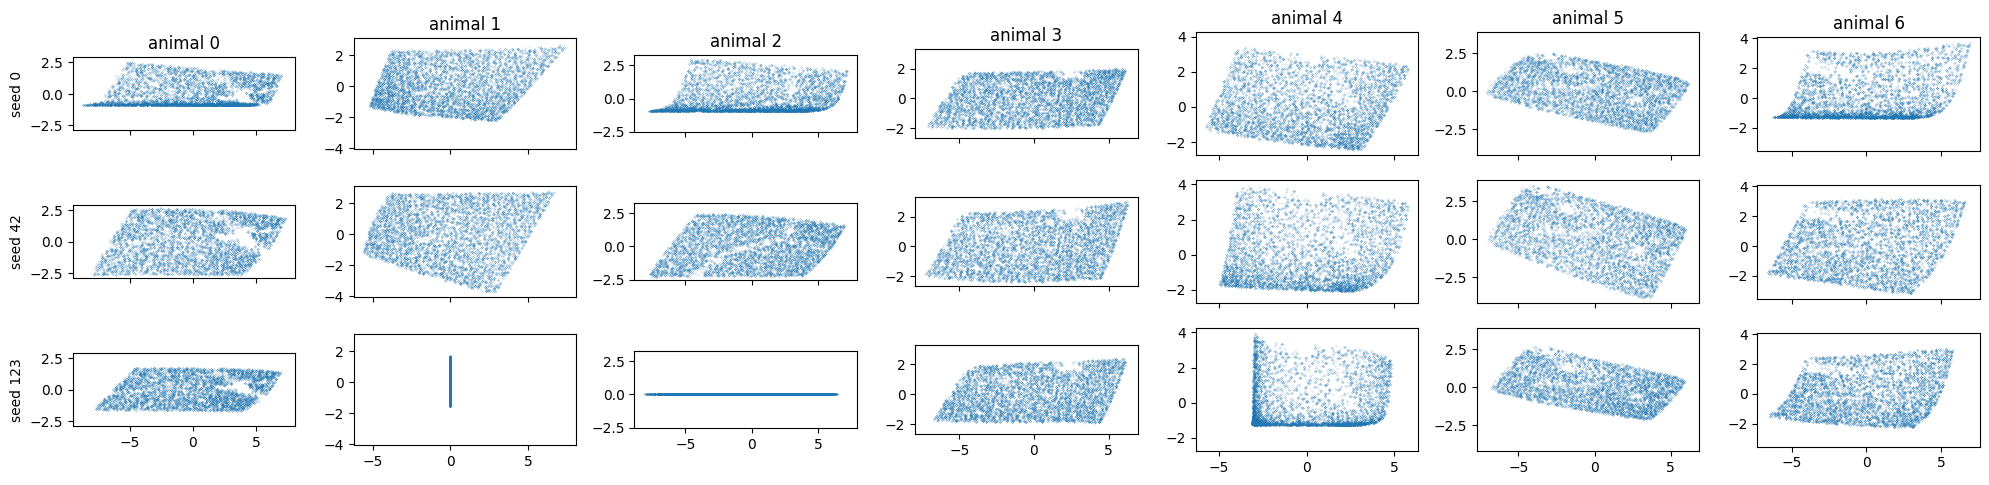

In [27]:
fig, axs = plt.subplots(3, 7, figsize=(20, 5), sharex='col', sharey='col')

for i in range(3):
    for j in range(7):
        grid = gaussian_grids[i][j]

        axs[i, j].scatter(grid[:, 0], grid[:, 1], s=0.01)
        axs[i, j].set_aspect('equal')
        if i == 0:
            axs[i, j].set_title(f'animal {j}')
        if j == 0:
            axs[i, j].set_ylabel(f'seed {[0, 42, 123][i]}')
plt.tight_layout()

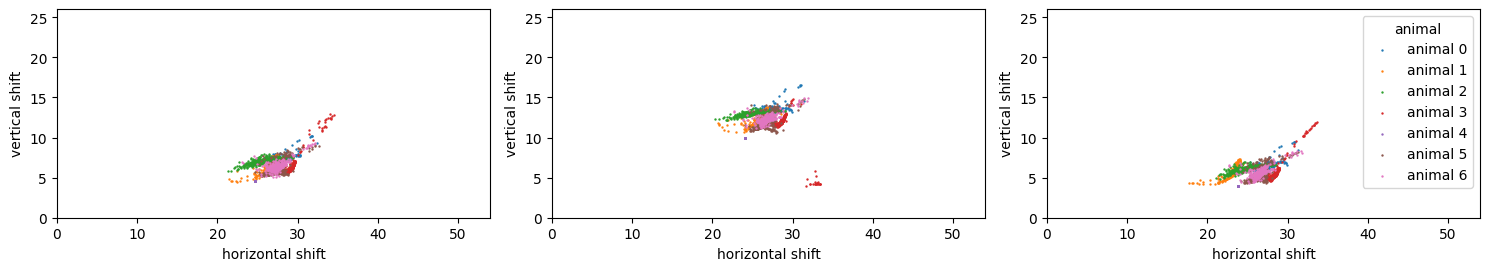

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    for j in range(7):
        axs[i].scatter(gaussian_shifts[i][j][:, 0], gaussian_shifts[i][j][:, 1], s=.5, label=f'animal {j}')
    axs[i].set_xlim(0, 54)
    axs[i].set_ylim(0, 26)
    # axs[i].set_xlim(-1, 1)
    # axs[i].set_ylim(-1, 1)

    axs[i].set_xlabel('horizontal shift')
    axs[i].set_ylabel('vertical shift')
    axs[i].set_aspect('equal')

plt.legend(title='animal')
plt.tight_layout()
plt.show()

# for shift, key in zip(shifts, data_keys):
#     plt.scatter(shift[:, 0], shift[:, 1], s=.5, label=key)


## factorized

In [18]:
num_batches = 3

factorized_grids = []
factorized_shifts = []
pupils = []

for path in factorized_paths:
# for path in [
#     'runs/factorized/fourier96_shifterreg1e4_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifterreg1e5_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifterreg1e6_seed0/model_weights.pth',
# ]:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.train();
    
    model_grids = []
    model_shifts = []
    model_pupils = []

    for key in data_keys:
        single = model.readout[key].normalized_spatial().detach().cpu()
        n, h, w = single.shape
        y = single.sum(dim=2)  # n, h
        x = single.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        # idx = single.view(-1, h * w).argmax(1)
        # y_max = idx // w
        # x_max = idx % w
        # grid = torch.stack([x_max, y_max], dim=1)

        grid = torch.stack([x_avg, y_avg], dim=1)
        grid_mean = grid.mean(dim=0, keepdim=True, dtype=torch.float32)
        # grid_centered = grid - grid_mean
        grid_centered = grid
        
        batch_num = 0

        shifts_batches = []
        pupils_batches = []
        for batch in dataloaders['validation'][key]:
            batch_num += 1
            img, _, _, pupil = batch
            if key == '26872-17-20':
                pupil[:] = 0
            shift = model.shifter[key](pupil, None).detach().cpu()
            shift[:, 0] = (shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
            shift[:, 1] = (shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]

            shift = -shift# + grid_mean
            shifts_batches.append(shift)
            pupils_batches.append(pupil.cpu())

            if batch_num == num_batches:
                break
            
        model_grids.append(grid_centered)
        model_shifts.append(torch.cat(shifts_batches))
        model_pupils.append(torch.cat(pupils_batches))
    factorized_grids.append(model_grids)
    factorized_shifts.append(model_shifts)
    pupils.append(model_pupils)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([7334, 2])
torch.Size([7334])
torch.Size([8098, 2])
torch.Size([8098])
torch.Size([8107, 2])
torch.Size([8107])
torch.Size([8372, 2])
torch.Size([8372])
torch.Size([7776, 2])
torch.Size([7776])
torch.Size([7344, 2])
torch.Size([7344])
torch.Size([7538, 2])
torch.Size([7538])


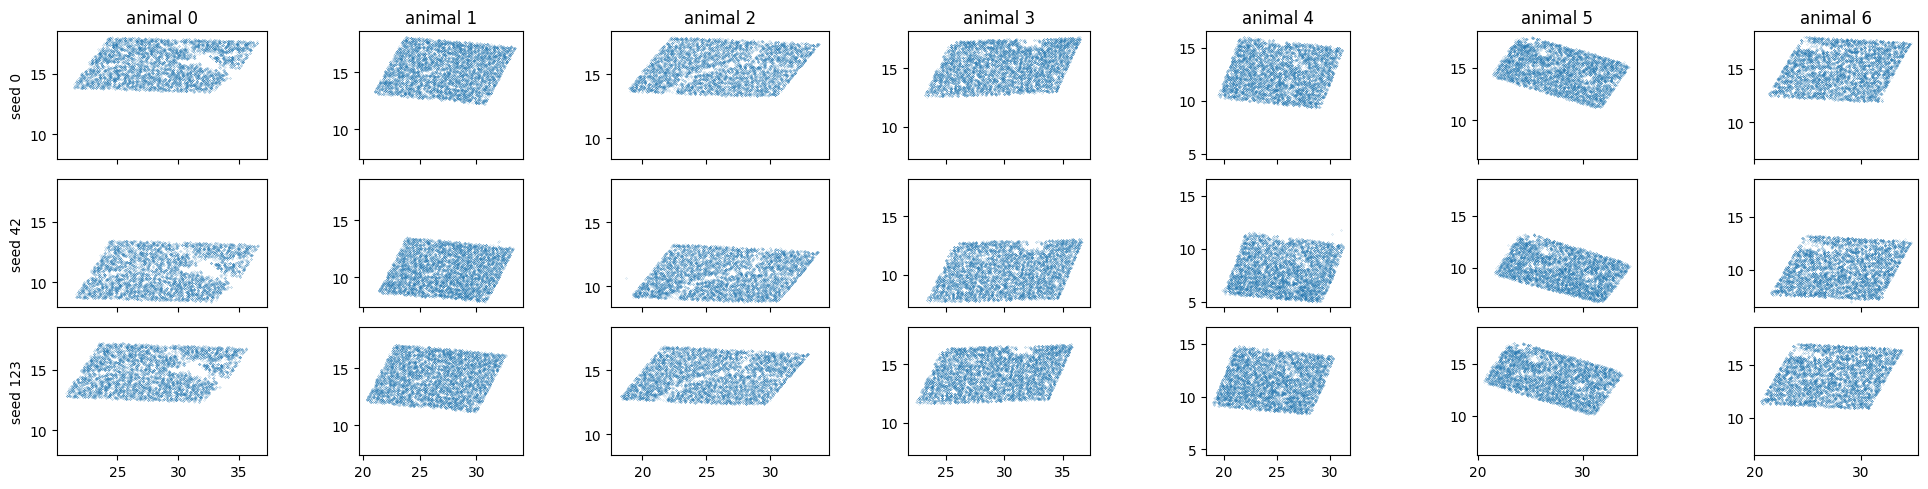

In [19]:
fig, axs = plt.subplots(3, 7, figsize=(20, 5), sharex='col', sharey='col')

for i in range(3):
    for j in range(7):
        avg = factorized_grids[i][j]
        avg_centered = avg# - avg.mean(dim=0)

        axs[i, j].scatter(avg_centered[:, 0], avg_centered[:, 1], s=0.01)
        axs[i, j].set_aspect('equal')
        if i == 0:
            axs[i, j].set_title(f'animal {j}')
        if j == 0:
            axs[i, j].set_ylabel(f'seed {[0, 42, 123][i]}')
plt.tight_layout()

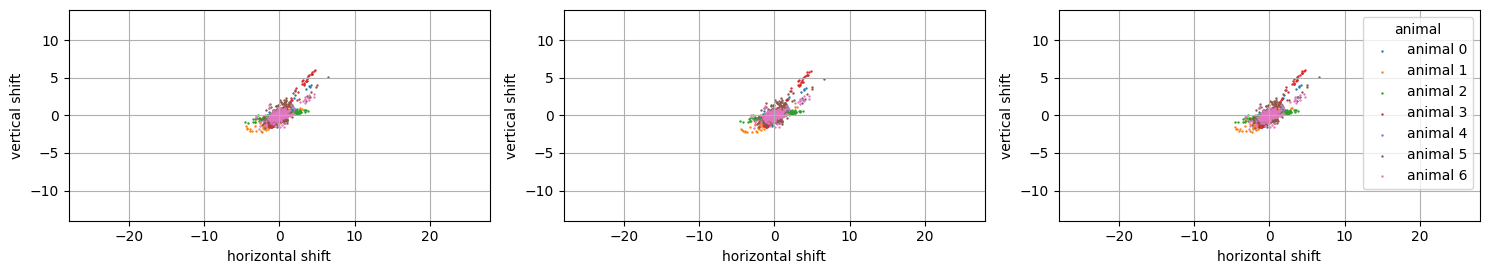

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    for j in range(7):
        axs[i].scatter(factorized_shifts[i][j][:, 0], factorized_shifts[i][j][:, 1], s=.5, label=f'animal {j}')
    # axs[i].set_xlim(0, w)
    # axs[i].set_ylim(0, h)
    axs[i].set_xlim(-w/2, w/2)
    axs[i].set_ylim(-h/2, h/2)

    axs[i].set_xlabel('horizontal shift')
    axs[i].set_ylabel('vertical shift')
    axs[i].set_aspect('equal')
    axs[i].grid()

plt.legend(title='animal')
plt.tight_layout()
plt.show()

# for shift, key in zip(shifts, data_keys):
#     plt.scatter(shift[:, 0], shift[:, 1], s=.5, label=key)

In [8]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
model.load_state_dict(torch.load(factorized_paths[0]))
model.to(device)
model.train();

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [17]:
d = model.readout[data_keys[3]].retinotopy_spatial
w = d.smooth_w.detach().cpu()
b = d.smooth_b.detach().cpu()

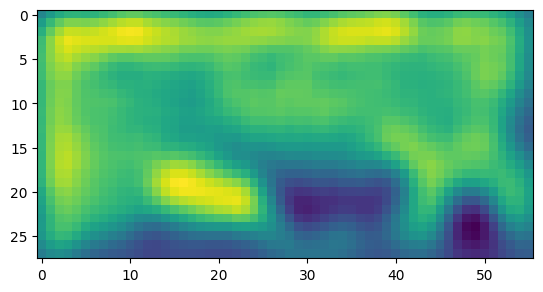

In [22]:
plt.imshow(w[3])

In [13]:
model.shifter[data_keys[6]].mlp[0].weight

Parameter containing:
tensor([[-0.7421, -0.1405],
        [-0.5288, -0.4051]], device='cuda:7', requires_grad=True)

In [39]:
num_batches = 3

factorized_grids = []
factorized_shifts = []
pupils = []

for path in factorized_paths:
# for path in [
#     'runs/factorized/fourier96_shifterreg1e4_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifterreg1e5_seed0/model_weights.pth',
#     'runs/factorized/fourier96_shifterreg1e6_seed0/model_weights.pth',
# ]:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.train();
    
    model_grids = []
    model_shifts = []
    model_pupils = []

    for key in data_keys:
        animal_grids = []
        for batch in dataloaders['validation'][key]:
            batch_num += 1
            img, _, _, pupil = batch
            if key == '26872-17-20':
                pupil[:] = 0

            # pupil = torch.zeros((2, ), device=device, dtype=torch.float32)
            single = torch.stack([
                model.readout[key].normalized_spatial(pup).detach().cpu()
                for pup in pupil
            ])
            print(single.shape)
            b, n, h, w = single.shape
            y = single.sum(dim=3)  # b, n, h
            x = single.sum(dim=2)  # b, n, w

            y_pos = torch.arange(h)[None, None, :].expand(b, n, h)
            x_pos = torch.arange(w)[None, None, :].expand(b, n, w)

            y_avg = (y_pos * y).sum(dim=2)
            x_avg = (x_pos * x).sum(dim=2)
            
            # idx = single.view(-1, h * w).argmax(1)
            # y_max = idx // w
            # x_max = idx % w
            # grid = torch.stack([x_max, y_max], dim=1)

            grid = torch.stack([x_avg, y_avg], dim=2)
            animal_grids.append(grid)
        model_grids.append(torch.cat(animal_grids))
            # grid_mean = grid.mean(dim=0, keepdim=True, dtype=torch.float32)
            # grid_centered = grid - grid_mean
        # grid_centered = grid
        
        # batch_num = 0

        # shifts_batches = []
        # pupils_batches = []
            # shift = model.shifter[key](pupil, None).detach().cpu()
        #     shift[:, 0] = (shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
        #     shift[:, 1] = (shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]

        #     shift = -shift + grid_mean
        #     shifts_batches.append(shift)
        #     pupils_batches.append(pupil.cpu())

        #     if batch_num == num_batches:
        #         break
            
        # model_shifts.append(torch.cat(shifts_batches))
        # model_pupils.append(torch.cat(pupils_batches))
    factorized_grids.append(model_grids)
    # factorized_shifts.append(model_shifts)
    # pupils.append(model_pupils)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


torch.Size([128, 7334, 28, 56])
torch.Size([128, 7334, 28, 56])
torch.Size([128, 7334, 28, 56])
torch.Size([112, 7334, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([115, 8098, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([112, 8107, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([11, 8372, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([112, 7776, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([116, 7344, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([113, 7538, 28, 56])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([128, 7334, 28, 56])
torch.Size([128, 7334, 28, 56])
torch.Size([128, 7334, 28, 56])
torch.Size([112, 7334, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([115, 8098, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([112, 8107, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([11, 8372, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([112, 7776, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([116, 7344, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([113, 7538, 28, 56])


Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


torch.Size([128, 7334, 28, 56])
torch.Size([128, 7334, 28, 56])
torch.Size([128, 7334, 28, 56])
torch.Size([112, 7334, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([128, 8098, 28, 56])
torch.Size([115, 8098, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([128, 8107, 28, 56])
torch.Size([112, 8107, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([128, 8372, 28, 56])
torch.Size([11, 8372, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([128, 7776, 28, 56])
torch.Size([112, 7776, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([128, 7344, 28, 56])
torch.Size([116, 7344, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([128, 7538, 28, 56])
torch.Size([113, 7538, 28, 56])


In [50]:
factorized_grids[0][2].shape

torch.Size([496, 8107, 2])

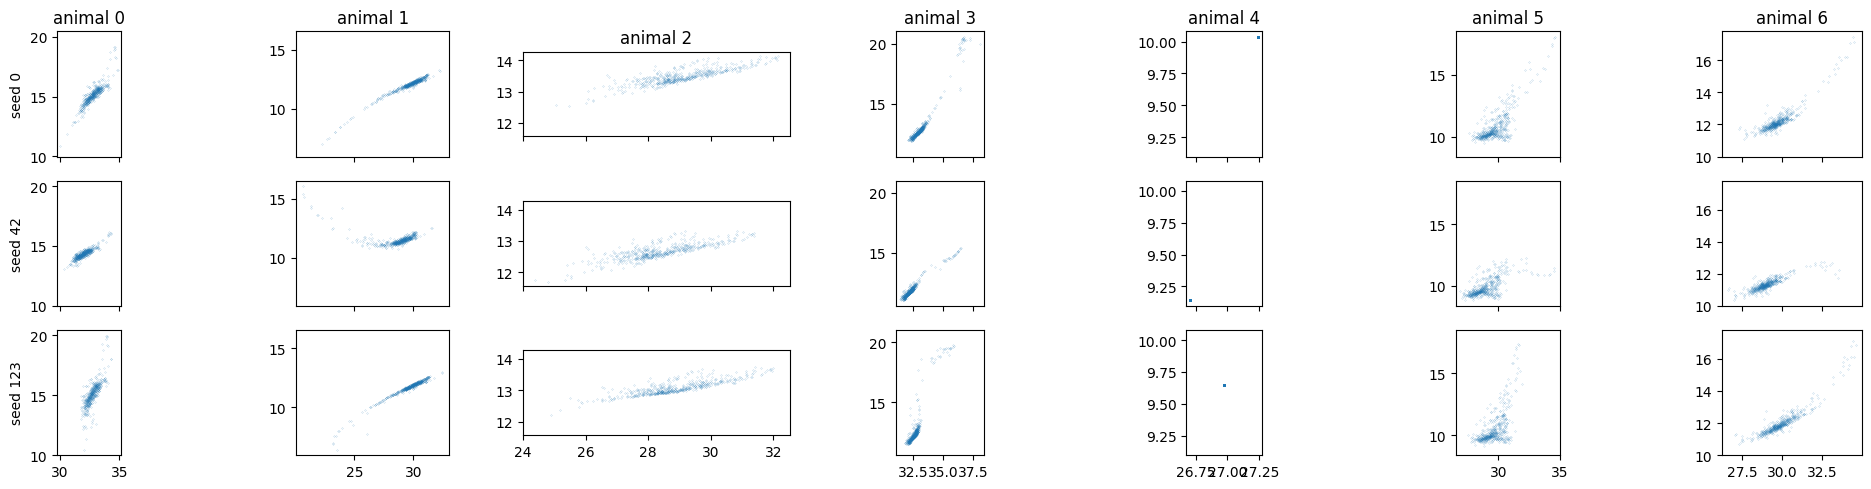

In [59]:
fig, axs = plt.subplots(3, 7, figsize=(20, 5), sharex='col', sharey='col')

for i in range(3):
    for j in range(7):
        avg = factorized_grids[i][j][:, 5]
        
        axs[i, j].scatter(avg[:, 0], avg[:, 1], s=0.01)
        axs[i, j].set_aspect('equal')
        if i == 0:
            axs[i, j].set_title(f'animal {j}')
        if j == 0:
            axs[i, j].set_ylabel(f'seed {[0, 42, 123][i]}')
plt.tight_layout()

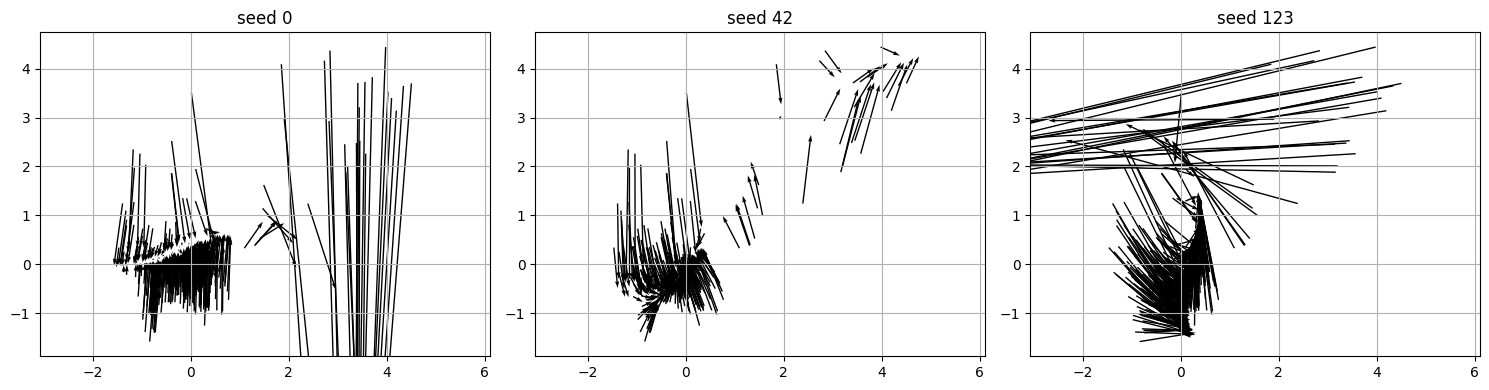

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# X: input points
# Y: output points
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
animal_id = 3

for i in range(3):
    X = -pupils[i][animal_id]
    Y = factorized_shifts[i][animal_id]

    # Xc = X - X.mean(0, keepdim=True)
    # X = Xc / (Xc.std(0, keepdim=True))

    Yc = Y - Y.mean(0, keepdim=True)
    Y = Yc / (Yc.std(0, keepdim=True))

    dx = Y[:, 0] - X[:, 0]
    dy = Y[:, 1] - X[:, 1]

    axs[i].quiver(
        X[:, 0], X[:, 1],  # arrow origins
        dx, dy,            # arrow directions
        angles='xy',
        scale_units='xy',
        scale=1
    )

    # plt.scatter(X[:, 0], X[:, 1], label='input')
    # plt.scatter(Y[:, 0], Y[:, 1], label='output')

    axs[i].axis('equal')
    axs[i].grid()
    axs[i].set_title(f'seed {[0,  42, 123][i]}')
plt.tight_layout()
plt.show()

# RF distances

## factorized

In [48]:
rfs = [[] for _ in range(3)]
for model_idx in range(3):
    for animal_idx in range(7):
        rfs[model_idx].append(
            # factorized_grids [model_idx][animal_idx].unsqueeze(1)
            factorized_shifts[model_idx][animal_idx].unsqueeze(0)
        )

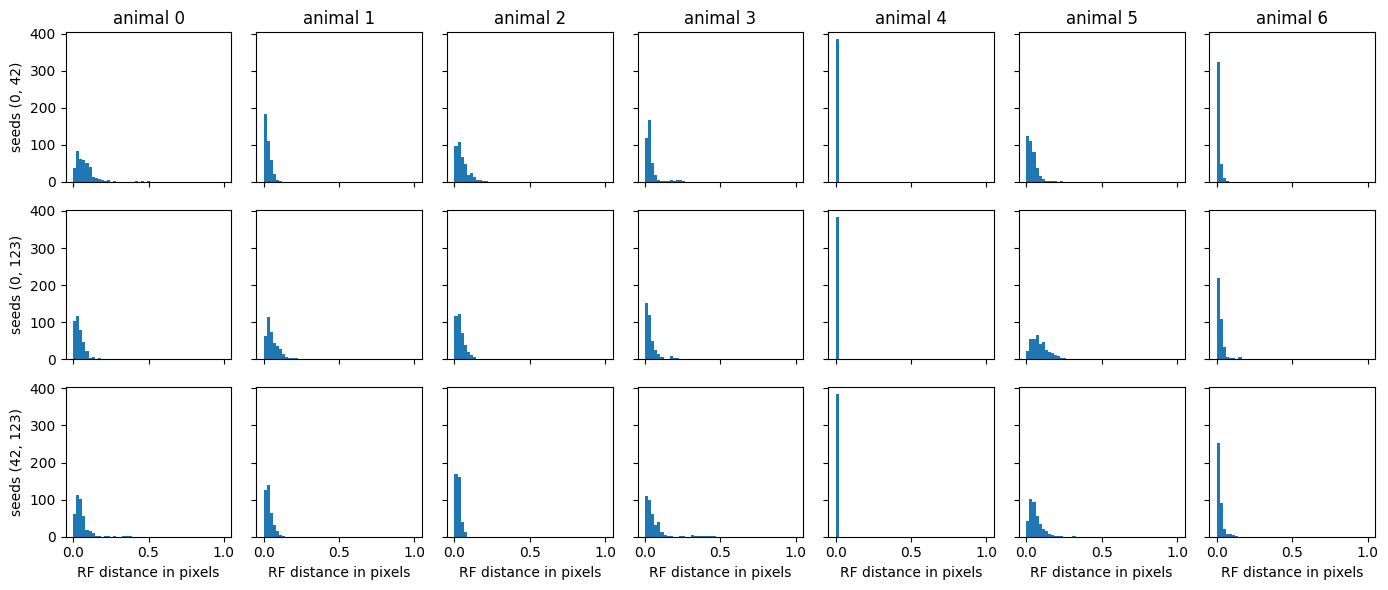

In [52]:
fig, axs = plt.subplots(3, 7, figsize=(14, 6), sharex=True, sharey=True)
bins = torch.linspace(0, 1, 50)

for k, (i, j) in enumerate(zip([0, 0, 1], [1, 2, 2])):
    for animal_idx in range(7):
        dist = (rfs[i][animal_idx] - rfs[j][animal_idx]).flatten(0, 1).pow(2).sum(-1).sqrt()
        axs[k, animal_idx].hist(dist, bins=bins)
        if k == 0:
            axs[k, animal_idx].set_title(f'animal {animal_idx}')
        if k == 2:
            axs[k, animal_idx].set_xlabel('RF distance in pixels')
        if animal_idx == 0:
            axs[k, animal_idx].set_ylabel(f'seeds {[(0, 42), (0, 123), (42, 123)][k]}')
plt.tight_layout()
plt.show()

## gaussian

In [35]:
rfs = [[] for _ in range(3)]
for model_idx in range(3):
    for animal_idx in range(7):
        rfs[model_idx].append(
            gaussian_grids [model_idx][animal_idx].unsqueeze(1) +
            gaussian_shifts[model_idx][animal_idx].unsqueeze(0)
        )

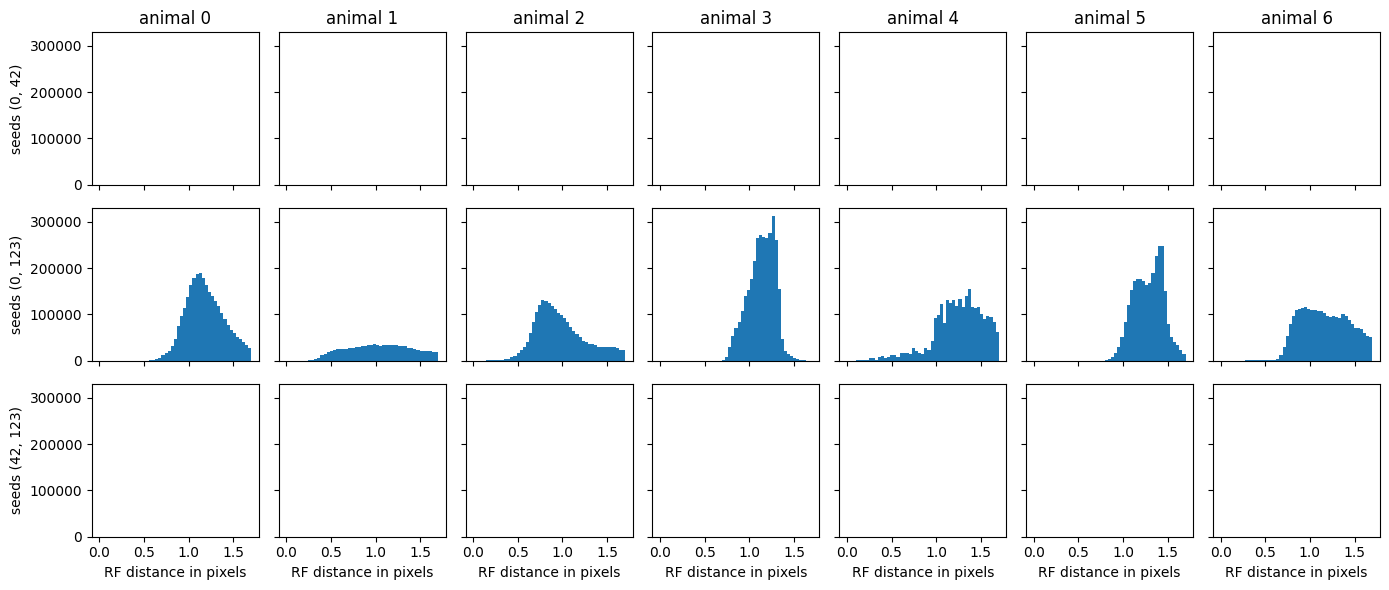

In [ ]:
fig, axs = plt.subplots(3, 7, figsize=(14, 6), sharex=True, sharey=True)
bins = torch.linspace(0, 1.7, 50)

for k, (i, j) in enumerate(zip([0, 0, 1], [1, 2, 2])):
    for animal_idx in range(7):
        dist = (rfs[i][animal_idx] - rfs[j][animal_idx]).flatten(0, 1).pow(2).sum(-1).sqrt()
        axs[k, animal_idx].hist(dist, bins=bins)
        if k == 0:
            axs[k, animal_idx].set_title(f'animal {animal_idx}')
        if k == 2:
            axs[k, animal_idx].set_xlabel('RF distance in pixels')
        if animal_idx == 0:
            axs[k, animal_idx].set_ylabel(f'seeds {[(0, 42), (0, 123), (42, 123)][k]}')
plt.tight_layout()
plt.show()

# fourier basis analysis 

In [73]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
model.load_state_dict(torch.load(factorized_paths[0], map_location='cpu'))
# model.to('cpu')
model.train();

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [74]:
retinotopy = model.readout[data_keys[0]].retinotopy_spatial
linear = retinotopy.mlp[0]
linear.weight.requires_grad = False# = linear.weight.detach()
linear.bias.requires_grad = False# = linear.bias.detach()

In [75]:
n = 10
x = torch.linspace(-1, 1, steps=10)
y = torch.zeros(10)
grid = torch.stack([y, x], axis=-1)

coeffs = linear(grid)
masks = torch.einsum('nk,khw->nhw', coeffs, retinotopy.basis)

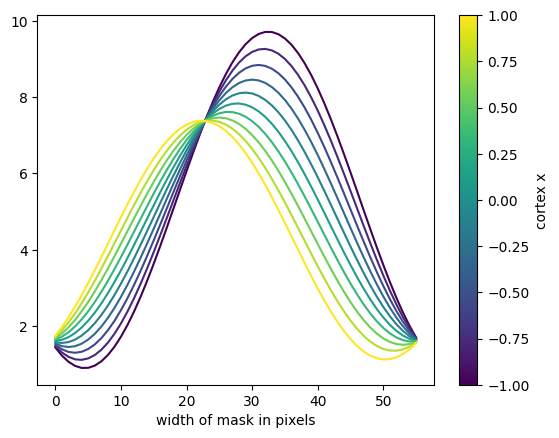

In [77]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

n = len(masks)
cmap = cm.viridis
norm = mcolors.Normalize(vmin=-1, vmax=1)

values = torch.linspace(-1, 1, n)  # maps each line to a value in [-1, 1]

fig, ax = plt.subplots()

for i, p in enumerate(masks):
    s = p[13, :]
    ax.plot(torch.arange(s.shape[0]), s, color=cmap(norm(values[i])))

ax.set_xlabel('width of mask in pixels')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='cortex x')
plt.show()

# 80 basis model

In [79]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config_old)
model.load_state_dict(torch.load(factorized_paths_old[0], map_location='cpu'))
model.train();

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [80]:
retinotopy = model.readout[data_keys[0]].retinotopy_spatial
linear = retinotopy.mlp[0]
linear.weight.requires_grad = False# = linear.weight.detach()
linear.bias.requires_grad = False# = linear.bias.detach()

In [81]:
n = 10
x = torch.linspace(-1, 1, steps=10)
y = torch.zeros(10)
grid = torch.stack([y, x], axis=-1)

coeffs = linear(grid)
masks = torch.einsum('nk,khw->nhw', coeffs, retinotopy.basis)

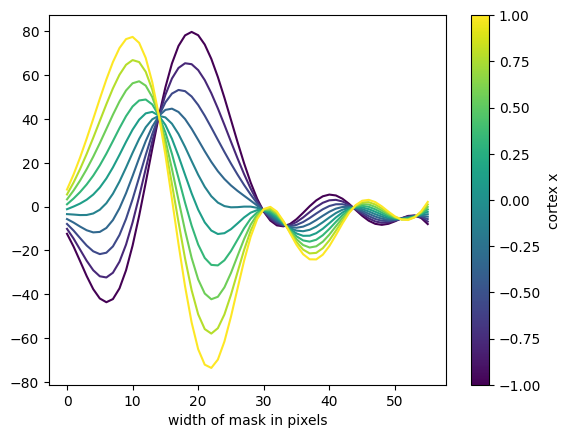

In [82]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

n = len(masks)
cmap = cm.viridis
norm = mcolors.Normalize(vmin=-1, vmax=1)

values = torch.linspace(-1, 1, n)  # maps each line to a value in [-1, 1]

fig, ax = plt.subplots()

for i, p in enumerate(masks):
    s = p[13, :]
    ax.plot(torch.arange(s.shape[0]), s, color=cmap(norm(values[i])))

ax.set_xlabel('width of mask in pixels')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='cortex x')
plt.show()

# training analysis

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


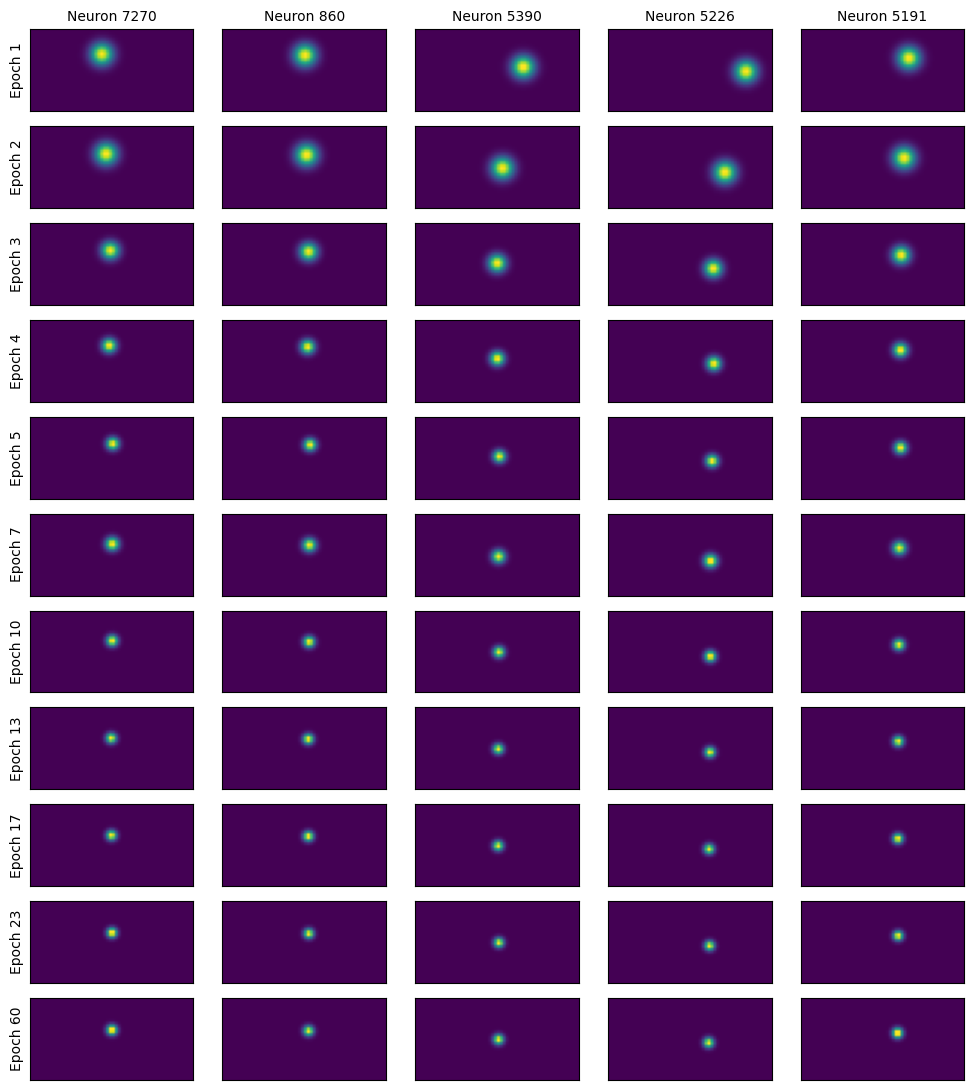

In [40]:
base_path = 'runs/factorized/fourier96_gaussian_epoch_cp_2x2shift_seed42/cps/'
animal_id = 0
n_neurons = 5
neuron_ids = None

epochs = [1, 2, 3, 4, 5, 7, 10, 13, 17, 23, 60]

fig, axs = plt.subplots(len(epochs), 5, figsize=(10, 11))

for i in range(len(epochs)):
    path = base_path + f'model_weights{epochs[i]}.pth'
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.train()
    spatial = model.readout[data_keys[animal_id]].normalized_spatial().detach()
    if neuron_ids is None:
        neuron_ids = np.random.choice(spatial.shape[0], n_neurons)
    for j, neuron_id in enumerate(neuron_ids):
        ax = axs[i, j]
        ax.imshow(spatial[neuron_id])
        ax.set_xticks([])
        ax.set_yticks([])

        # Column labels (neuron ids) on top row only
        if i == 0:
            ax.set_title(f'Neuron {neuron_id}', fontsize=10)

        # Row labels (epochs) on first column only
        if j == 0:
            ax.set_ylabel(f'Epoch {epochs[i]}', fontsize=10)

plt.tight_layout()
plt.show()

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

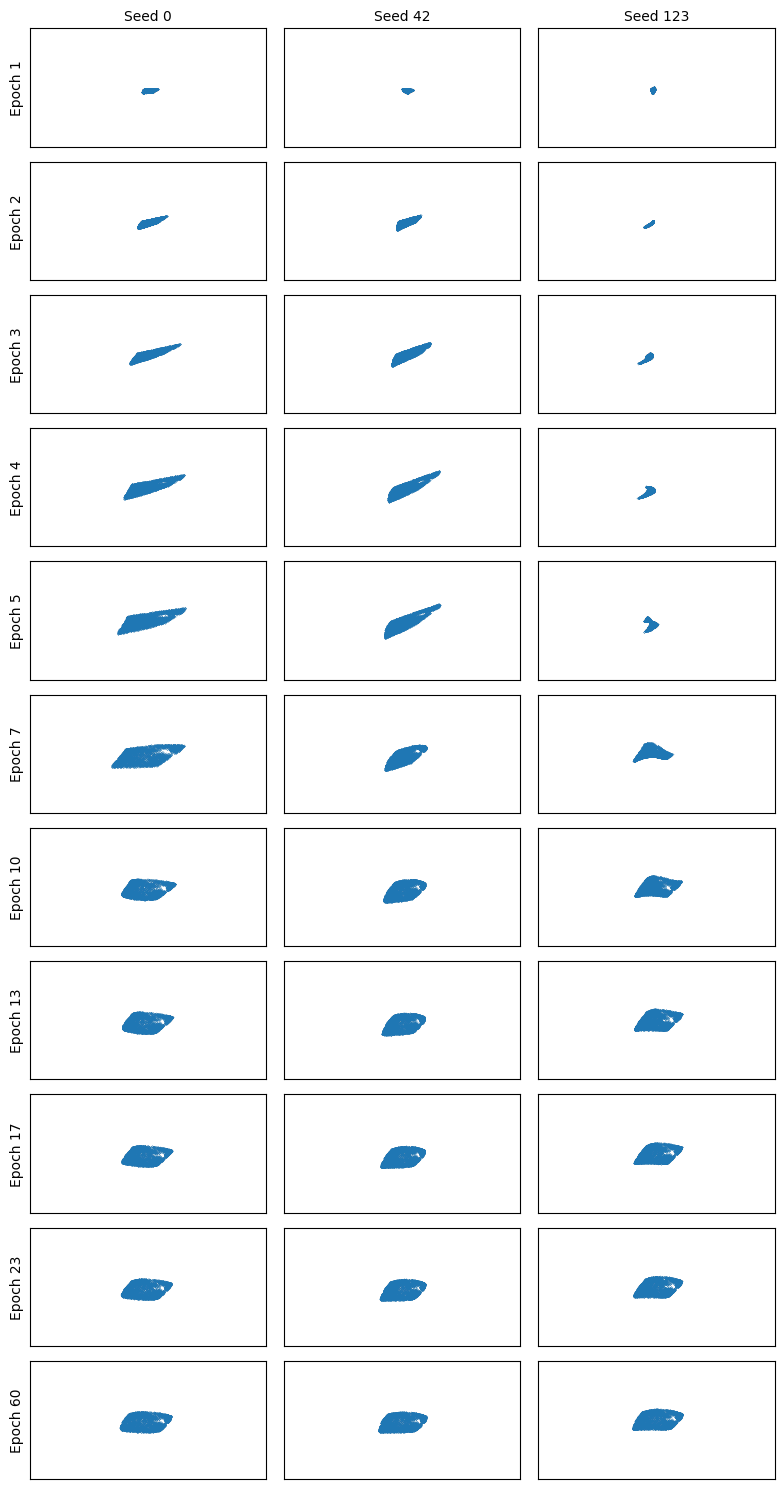

In [42]:
base_paths = [
    'runs/factorized/fourier96_epoch_cp_2x2shift_seed0/cps/',
    'runs/factorized/fourier96_epoch_cp_2x2shift_seed42/cps/',
    'runs/factorized/fourier96_epoch_cp_2x2shift_seed123/cps/',
]
animal_id = 0
n_neurons = 1
neuron_ids = None

epochs = [1, 2, 3, 4, 5, 7, 10, 13, 17, 23, 60]
# epochs = [1, 60]

fig, axs = plt.subplots(len(epochs), 3, figsize=(8, 15))

for i in range(len(epochs)):
    for j, base_path in enumerate(base_paths):
        path = base_path + f'model_weights{epochs[i]}.pth'
        model = stacked_core_full_gauss_readout(dataloaders, random_seed, **factorized_model_config_old)
        model.load_state_dict(torch.load(path, map_location='cpu'))
        model.train()
        # spatial = model.readout[data_keys[animal_id]].normalized_spatial().detach()
        
        single = model.readout[data_keys[animal_id]].normalized_spatial().detach().cpu()
        n, h, w = single.shape
        y = single.sum(dim=2)  # n, h
        x = single.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        ax = axs[i, j]
        ax.scatter(x_avg, y_avg, s=0.01)
        ax.set_xlim(0, w)
        ax.set_ylim(0, h)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        if neuron_ids is None:
            neuron_ids = np.random.choice(spatial.shape[0], n_neurons)
        # for j, neuron_id in enumerate(neuron_ids):

        # ax.scatter
        # ax.imshow(spatial[neuron_ids[0]])

        # Column labels (neuron ids) on top row only
        if i == 0:
            ax.set_title(f'Seed {[0, 42, 123][j]}', fontsize=10)

        # Row labels (epochs) on first column only
        if j == 0:
            ax.set_ylabel(f'Epoch {epochs[i]}', fontsize=10)

plt.tight_layout()
plt.show()